## <Center> LULC Modification

In [5]:
import numpy as np
import rasterio
from scipy.ndimage import distance_transform_edt

def modify_lulc_for_glacier_retreat(input_lulc_path, output_lulc_path, 
                                      debris_reduction_km2, clean_reduction_km2):
    """
    Modify LULC by converting glacier pixels to bareland based on OGGM projections.
    
    Parameters:
    -----------
    input_lulc_path : str
        Path to input LULC raster
    output_lulc_path : str
        Path to save modified LULC
    debris_reduction_km2 : float
        Area of debris glacier to reduce (km²)
    clean_reduction_km2 : float
        Area of clean glacier to reduce (km²)
    """
    
    with rasterio.open(input_lulc_path) as src:
        lulc = src.read(1)
        profile = src.profile
        transform = src.transform
        
        # Calculate pixel area in km²
        pixel_width = abs(transform[0])
        pixel_height = abs(transform[4])
        pixel_area_km2 = (pixel_width * pixel_height) / 1_000_000  # Convert m² to km²
        
        print(f"Pixel resolution: {pixel_width}m x {pixel_height}m")
        print(f"Pixel area: {pixel_area_km2:.6f} km²")
        
        # Calculate number of pixels to convert
        debris_pixels_to_convert = int(debris_reduction_km2 / pixel_area_km2)
        clean_pixels_to_convert = int(clean_reduction_km2 / pixel_area_km2)
        
        print(f"\nDebris glacier: {debris_reduction_km2} km² = {debris_pixels_to_convert} pixels")
        print(f"Clean glacier: {clean_reduction_km2} km² = {clean_pixels_to_convert} pixels")
        
        # Count current pixels
        unique, counts = np.unique(lulc, return_counts=True)
        class_counts = dict(zip(unique, counts))
        print(f"\nOriginal class 7 (debris) pixels: {class_counts.get(7, 0)}")
        print(f"Original class 8 (clean) pixels: {class_counts.get(8, 0)}")
        print(f"Original class 4 (bareland) pixels: {class_counts.get(4, 0)}")
        
        # Create a copy for modification
        modified_lulc = lulc.copy()
        
        # Process debris glaciers (class 7)
        modified_lulc = convert_glacier_margins(
            modified_lulc, 
            glacier_class=7, 
            bareland_class=4,
            n_pixels=debris_pixels_to_convert
        )
        
        # Process clean glaciers (class 8)
        modified_lulc = convert_glacier_margins(
            modified_lulc, 
            glacier_class=8, 
            bareland_class=4,
            n_pixels=clean_pixels_to_convert
        )
        
        # Count modified pixels
        unique, counts = np.unique(modified_lulc, return_counts=True)
        class_counts_new = dict(zip(unique, counts))
        print(f"\nModified class 7 (debris) pixels: {class_counts_new.get(7, 0)}")
        print(f"Modified class 8 (clean) pixels: {class_counts_new.get(8, 0)}")
        print(f"Modified class 4 (bareland) pixels: {class_counts_new.get(4, 0)}")
        
        print(f"\nPixels converted:")
        print(f"  Debris (7→4): {class_counts.get(7, 0) - class_counts_new.get(7, 0)}")
        print(f"  Clean (8→4): {class_counts.get(8, 0) - class_counts_new.get(8, 0)}")
        print(f"  Total bareland gain: {class_counts_new.get(4, 0) - class_counts.get(4, 0)}")
        
        # Save modified LULC
        with rasterio.open(output_lulc_path, 'w', **profile) as dst:
            dst.write(modified_lulc, 1)
        
        print(f"\nModified LULC saved to: {output_lulc_path}")
        return modified_lulc


def convert_glacier_margins(lulc, glacier_class, bareland_class, n_pixels):
    """
    Convert glacier pixels to bareland, prioritizing margins/edges.
    Uses distance transform to identify pixels furthest from glacier center.
    """
    if n_pixels <= 0:
        return lulc
    
    # Create binary mask for this glacier class
    glacier_mask = (lulc == glacier_class)
    
    # Check if we have enough pixels
    available_pixels = np.sum(glacier_mask)
    if available_pixels == 0:
        print(f"Warning: No pixels found for class {glacier_class}")
        return lulc
    
    if n_pixels > available_pixels:
        print(f"Warning: Requested {n_pixels} pixels but only {available_pixels} available for class {glacier_class}")
        n_pixels = available_pixels
    
    # Distance transform from glacier edges (higher = more central)
    # Invert so edges have higher values
    distance_from_edge = distance_transform_edt(glacier_mask)
    distance_from_center = distance_from_edge.max() - distance_from_edge
    
    # Only consider glacier pixels
    distance_from_center[~glacier_mask] = -9999
    
    # Get indices of glacier pixels sorted by distance from center (edges first)
    glacier_indices = np.where(glacier_mask)
    distances = distance_from_center[glacier_indices]
    sorted_idx = np.argsort(-distances)  # Sort descending (edges first)
    
    # Select pixels to convert (from edges inward)
    pixels_to_convert_idx = sorted_idx[:n_pixels]
    rows_to_convert = glacier_indices[0][pixels_to_convert_idx]
    cols_to_convert = glacier_indices[1][pixels_to_convert_idx]
    
    # Convert selected pixels to bareland
    lulc[rows_to_convert, cols_to_convert] = bareland_class
    
    return lulc


# Example usage
if __name__ == "__main__":
    # Your parameters
    input_lulc = r"C:\Users\maran\Downloads\MERGED_UPDATED.tif"       #original LULC raster
    output_lulc = r"C:\Users\maran\Downloads\Ghizer_lulc_2065.tif"    #Output 
    
    # OGGM projections
    total_reduction = 175.21  # km²
    debris_fraction = 0.064
    clean_fraction = 0.936
    
    debris_reduction = total_reduction * debris_fraction  
    clean_reduction = total_reduction * clean_fraction   
    
    # Modify LULC
    modified_lulc = modify_lulc_for_glacier_retreat(
        input_lulc_path=input_lulc,
        output_lulc_path=output_lulc,
        debris_reduction_km2=debris_reduction,
        clean_reduction_km2=clean_reduction
    )

Pixel resolution: 180.0m x 180.0m
Pixel area: 0.032400 km²

Debris glacier: 11.21344 km² = 346 pixels
Clean glacier: 163.99656000000002 km² = 5061 pixels

Original class 7 (debris) pixels: 2768
Original class 8 (clean) pixels: 33285
Original class 4 (bareland) pixels: 300184

Modified class 7 (debris) pixels: 2422
Modified class 8 (clean) pixels: 28224
Modified class 4 (bareland) pixels: 305591

Pixels converted:
  Debris (7→4): 346
  Clean (8→4): 5061
  Total bareland gain: 5407

Modified LULC saved to: C:\Users\maran\Downloads\Ghizer_lulc_2065.tif


LULC VALIDATION REPORT

1. PIXEL COUNT COMPARISON:
------------------------------------------------------------

Original LULC:
  Class 4 (Bareland):        300,184 pixels
  Class 7 (Debris Glacier):  2,768 pixels
  Class 8 (Clean Glacier):   33,285 pixels

Modified LULC:
  Class 4 (Bareland):        301,986 pixels
  Class 7 (Debris Glacier):  2,653 pixels
  Class 8 (Clean Glacier):   31,598 pixels

2. AREA CHANGES:
------------------------------------------------------------

Bareland (Class 4):
  Change: +1,802 pixels (+58.38 km²)

Debris Glacier (Class 7):
  Change: -115 pixels (-3.73 km²)

Clean Glacier (Class 8):
  Change: -1,687 pixels (-54.66 km²)

Total Glacier Loss: 58.38 km²
Total Bareland Gain: 58.38 km²

3. MASS BALANCE CHECK:
------------------------------------------------------------
✓ PASSED: Glacier loss equals bareland gain
  1,802 pixels converted

4. SPATIAL CHANGE ANALYSIS:
------------------------------------------------------------
Total changed pixels: 1,802
  D

c:\Users\maran\miniconda3\envs\pcr_env\lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


✓ Visualization saved: lulc_validation.png


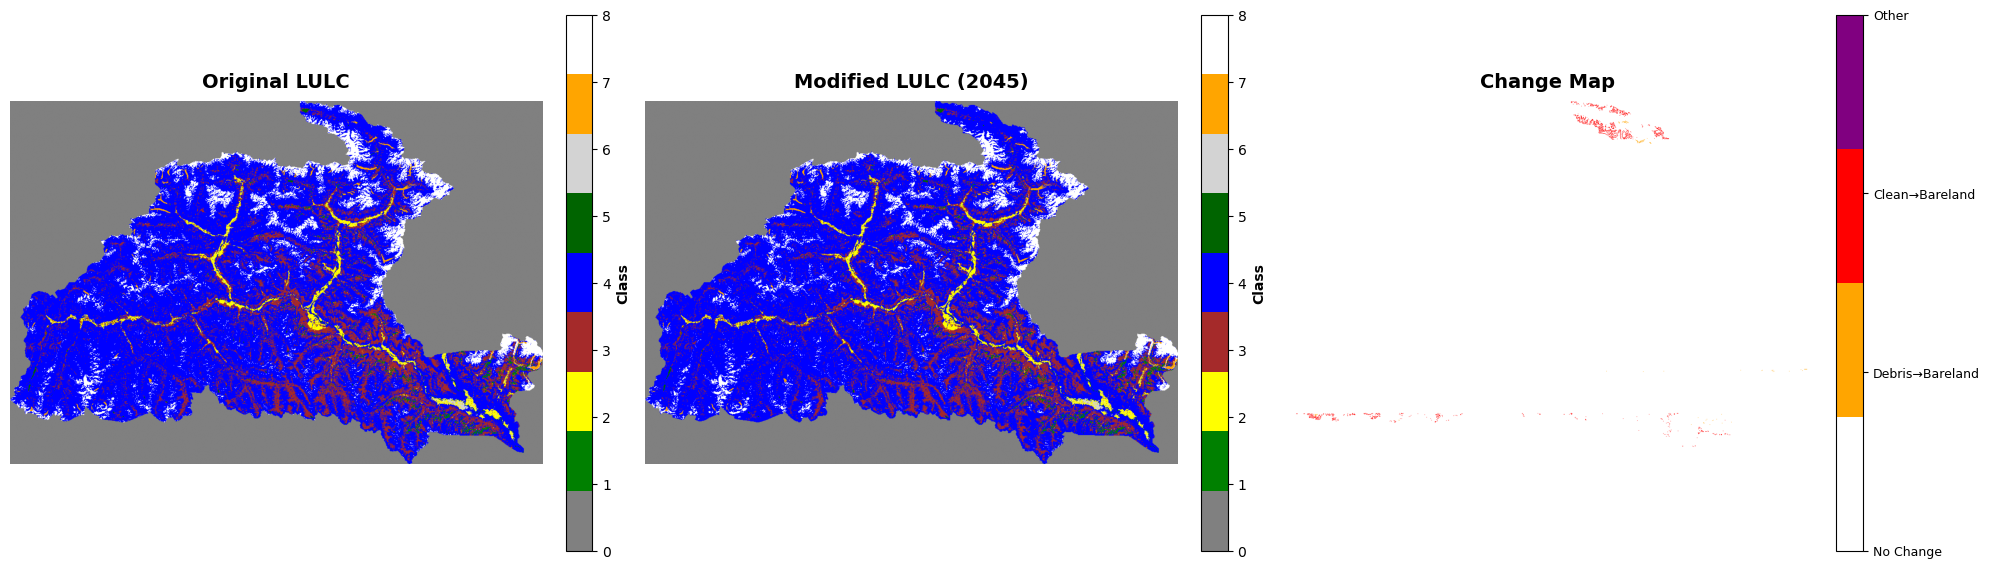


VALIDATION COMPLETE


In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def validate_lulc_changes(original_lulc_path, modified_lulc_path):
    """
    Validate and visualize LULC changes between original and modified files.
    """
    
    # Read both LULC files
    with rasterio.open(original_lulc_path) as src:
        original = src.read(1)
        transform = src.transform
        
    with rasterio.open(modified_lulc_path) as src:
        modified = src.read(1)
    
    # Calculate pixel area in km²
    pixel_width = abs(transform[0])
    pixel_height = abs(transform[4])
    pixel_area_km2 = (pixel_width * pixel_height) / 1_000_000
    
    print("="*60)
    print("LULC VALIDATION REPORT")
    print("="*60)
    
    # 1. Count pixels for each class
    print("\n1. PIXEL COUNT COMPARISON:")
    print("-" * 60)
    
    for lulc_name, lulc_data in [("Original", original), ("Modified", modified)]:
        unique, counts = np.unique(lulc_data, return_counts=True)
        class_counts = dict(zip(unique, counts))
        
        print(f"\n{lulc_name} LULC:")
        print(f"  Class 4 (Bareland):        {class_counts.get(4, 0):,} pixels")
        print(f"  Class 7 (Debris Glacier):  {class_counts.get(7, 0):,} pixels")
        print(f"  Class 8 (Clean Glacier):   {class_counts.get(8, 0):,} pixels")
    
    # 2. Calculate area changes
    print("\n2. AREA CHANGES:")
    print("-" * 60)
    
    orig_unique, orig_counts = np.unique(original, return_counts=True)
    orig_counts_dict = dict(zip(orig_unique, orig_counts))
    
    mod_unique, mod_counts = np.unique(modified, return_counts=True)
    mod_counts_dict = dict(zip(mod_unique, mod_counts))
    
    # Calculate changes
    bareland_change_pixels = mod_counts_dict.get(4, 0) - orig_counts_dict.get(4, 0)
    debris_change_pixels = mod_counts_dict.get(7, 0) - orig_counts_dict.get(7, 0)
    clean_change_pixels = mod_counts_dict.get(8, 0) - orig_counts_dict.get(8, 0)
    
    bareland_change_km2 = bareland_change_pixels * pixel_area_km2
    debris_change_km2 = debris_change_pixels * pixel_area_km2
    clean_change_km2 = clean_change_pixels * pixel_area_km2
    total_glacier_loss_km2 = abs(debris_change_km2) + abs(clean_change_km2)
    
    print(f"\nBareland (Class 4):")
    print(f"  Change: {bareland_change_pixels:+,} pixels ({bareland_change_km2:+.2f} km²)")
    
    print(f"\nDebris Glacier (Class 7):")
    print(f"  Change: {debris_change_pixels:+,} pixels ({debris_change_km2:+.2f} km²)")
    
    print(f"\nClean Glacier (Class 8):")
    print(f"  Change: {clean_change_pixels:+,} pixels ({clean_change_km2:+.2f} km²)")
    
    print(f"\nTotal Glacier Loss: {total_glacier_loss_km2:.2f} km²")
    print(f"Total Bareland Gain: {bareland_change_km2:.2f} km²")
    
    # 3. Check mass balance
    print("\n3. MASS BALANCE CHECK:")
    print("-" * 60)
    glacier_loss = abs(debris_change_pixels) + abs(clean_change_pixels)
    bareland_gain = bareland_change_pixels
    
    if glacier_loss == bareland_gain:
        print("✓ PASSED: Glacier loss equals bareland gain")
        print(f"  {glacier_loss:,} pixels converted")
    else:
        print("✗ WARNING: Mismatch detected!")
        print(f"  Glacier loss:   {glacier_loss:,} pixels")
        print(f"  Bareland gain:  {bareland_gain:,} pixels")
        print(f"  Difference:     {abs(glacier_loss - bareland_gain):,} pixels")
    
    # 4. Identify what changed
    print("\n4. SPATIAL CHANGE ANALYSIS:")
    print("-" * 60)
    
    # Find pixels that changed
    changed_mask = (original != modified)
    num_changed = np.sum(changed_mask)
    
    # Identify change types
    debris_to_bareland = np.sum((original == 7) & (modified == 4))
    clean_to_bareland = np.sum((original == 8) & (modified == 4))
    other_changes = num_changed - debris_to_bareland - clean_to_bareland
    
    print(f"Total changed pixels: {num_changed:,}")
    print(f"  Debris → Bareland: {debris_to_bareland:,} pixels ({debris_to_bareland * pixel_area_km2:.2f} km²)")
    print(f"  Clean → Bareland:  {clean_to_bareland:,} pixels ({clean_to_bareland * pixel_area_km2:.2f} km²)")
    if other_changes > 0:
        print(f"  Other changes:     {other_changes:,} pixels (⚠ Unexpected!)")
    
    # 5. Create visualization (3 plots instead of 4)
    print("\n5. GENERATING VISUALIZATIONS...")
    print("-" * 60)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
    fig.patch.set_facecolor("white")
    
    # Define colormap for LULC classes
    colors = ['gray', 'green', 'yellow', 'brown', 'blue', 'darkgreen', 'lightgray', 'orange', 'white']
    cmap = ListedColormap(colors[:9])
    
    # Plot 1: Original LULC
    im1 = axes[0].imshow(original, cmap=cmap, vmin=0, vmax=8)
    axes[0].set_title('Original LULC', fontsize=14, fontweight='bold', pad=10)
    axes[0].axis('off')
    cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label('Class', fontweight='bold')
    
    # Plot 2: Modified LULC
    im2 = axes[1].imshow(modified, cmap=cmap, vmin=0, vmax=8)
    axes[1].set_title('Modified LULC (2045)', fontsize=14, fontweight='bold', pad=10)
    axes[1].axis('off')
    cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_label('Class', fontweight='bold')
    
    # Plot 3: Change map
    change_map = np.zeros_like(original, dtype=float)
    change_map[original == modified] = 0  # No change
    change_map[(original == 7) & (modified == 4)] = 1  # Debris to bareland
    change_map[(original == 8) & (modified == 4)] = 2  # Clean to bareland
    change_map[(original != modified) & (change_map == 0)] = 3  # Other changes
    
    change_colors = ['white', 'orange', 'red', 'purple']
    change_cmap = ListedColormap(change_colors)
    
    im3 = axes[2].imshow(change_map, cmap=change_cmap, vmin=0, vmax=3)
    axes[2].set_title('Change Map', fontsize=14, fontweight='bold', pad=10)
    axes[2].axis('off')
    cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3])
    cbar3.ax.set_yticklabels(['No Change', 'Debris→Bareland', 'Clean→Bareland', 'Other'], fontsize=9)
    
    plt.tight_layout()
    plt.savefig('D:/Python_Work/test/lulc_validation_2045.png', dpi=300, bbox_inches='tight')
    print("✓ Visualization saved: lulc_validation.png")
    plt.show()
    
    print("\n" + "="*60)
    print("VALIDATION COMPLETE")
    print("="*60)
    
    return {
        'bareland_change_km2': bareland_change_km2,
        'debris_change_km2': debris_change_km2,
        'clean_change_km2': clean_change_km2,
        'total_glacier_loss_km2': total_glacier_loss_km2,
        'mass_balance_check': (glacier_loss == bareland_gain)
    }


# Run validation
original_lulc = r"C:\Users\maran\Downloads\MERGED_UPDATED.tif"
modified_lulc = r"C:\Users\maran\Downloads\Ghizer_lulc_2045.tif"

results = validate_lulc_changes(original_lulc, modified_lulc)

## <center> New LULC

In [4]:
import ee


In [4]:
import ee
ee.Authenticate()
ee.Initialize(project='ee-muqet100')


Successfully saved authorization token.


In [13]:
import ee
import geemap


# Initialize Earth Engine
ee.Initialize(project='ee-muqet100')


# ============================================================================
# 1. SETUP - REPLACE WITH YOUR ASSET PATHS
# ============================================================================

trainingData = ee.FeatureCollection('projects/ee-muqet100/assets/Hunza_Training')
studyArea = ee.FeatureCollection('projects/ee-muqet100/assets/Hunza_District').geometry()

# Years to process
years = [1995, 2000, 2005, 2010, 2015, 2020, 2025]

# LULC class definitions
lulcClasses = {
    1: 'Forest',
    2: 'Agriculture',
    3: 'Grassland',
    4: 'Bare Land',
    5: 'Water Bodies',
    6: 'Built-up',
    7: 'Snow/Glacier'
}

# Color palette for visualization
palette = [
    '006400',  # Forest - Dark Green
    'FFFF00',  # Agriculture - Yellow
    '90EE90',  # Grassland - Light Green
    'D2B48C',  # Bare Land - Tan
    '0000FF',  # Water Bodies - Blue
    'FF0000',  # Built-up - Red
    'FFFFFF'   # Snow/Glacier - White
]

# ============================================================================
# 2. CLOUD MASKING FUNCTIONS
# ============================================================================

def maskLandsat457(image):
    """Cloud masking for Landsat 4/5/7"""
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloudShadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(cloudShadow)

def maskLandsat89(image):
    """Cloud masking for Landsat 8/9"""
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloudShadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(cloudShadow)

# ============================================================================
# 3. BAND HARMONIZATION
# ============================================================================

def renameLandsat89(image):
    """Rename Landsat 8/9 bands to match Landsat 4/5/7"""
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL']
    )

# ============================================================================
# 4. COMPOSITE CREATION FUNCTION
# ============================================================================

def getAnnualComposite(year, startMonth, endMonth):
    """Create annual median composite for specified year"""
    startDate = ee.Date.fromYMD(year, startMonth, 1)
    endDate = ee.Date.fromYMD(year, endMonth, 30)
    
    if year < 1999:
        # Landsat 5 only
        collection = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
    
    elif year >= 1999 and year < 2013:
        # Landsat 5 and 7
        l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        collection = l5.merge(l7)
    
    elif year >= 2013 and year < 2022:
        # Landsat 7 and 8 (2013-2021)
        l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat89)
            .map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        collection = l7.merge(l8)
    
    else:
        # Landsat 8 and 9 for 2022+ (includes 2025)
        l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat89)
            .map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
            .filterBounds(studyArea)
            .filterDate(startDate, endDate)
            .map(maskLandsat89)
            .map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        
        collection = l8.merge(l9)
    
    print(f'Year {year} - Images found: {collection.size().getInfo()}')
    
    return collection.median().clip(studyArea)

# ============================================================================
# 5. SPECTRAL INDICES FUNCTION
# ============================================================================

def addIndices(image):
    """Add spectral indices to image"""
    # Rename bands for easier calculation
    img = image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
        ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2']
    )
    
    # Calculate indices
    ndvi = img.normalizedDifference(['NIR', 'R']).rename('NDVI')
    ndwi = img.normalizedDifference(['G', 'NIR']).rename('NDWI')
    ndbi = img.normalizedDifference(['SWIR1', 'NIR']).rename('NDBI')
    mndwi = img.normalizedDifference(['G', 'SWIR1']).rename('MNDWI')
    
    savi = img.expression(
        '((NIR - R) / (NIR + R + L)) * (1 + L)', {
            'NIR': img.select('NIR'),
            'R': img.select('R'),
            'L': 0.5
        }).rename('SAVI')
    
    bsi = img.expression(
        '((SWIR1 + R) - (NIR + B)) / ((SWIR1 + R) + (NIR + B))', {
            'SWIR1': img.select('SWIR1'),
            'R': img.select('R'),
            'NIR': img.select('NIR'),
            'B': img.select('B')
        }).rename('BSI')
    
    ndsi = img.normalizedDifference(['G', 'SWIR1']).rename('NDSI')
    
    return img.addBands([ndvi, ndwi, ndbi, mndwi, savi, bsi, ndsi])

# ============================================================================
# 6. CREATE COMPOSITES FOR ALL YEARS
# ============================================================================

print('=' * 60)
print('CREATING SATELLITE COMPOSITES...')
print('Years: 1995, 2000, 2005, 2010, 2015, 2020, 2025')
print('Date range: April to October (growing season)')
print('=' * 60)

composites = {}
compositesWithIndices = {}

for year in years:
    composites[year] = getAnnualComposite(year, 4, 10)
    compositesWithIndices[year] = addIndices(composites[year])

# ============================================================================
# 7. CLASSIFICATION PARAMETERS
# ============================================================================

classificationParams = {
    'numberOfTrees': 100,
    'minLeafPopulation': 1,
    'bagFraction': 0.5,
    
    'bands': ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2', 
              'NDVI', 'NDWI', 'NDBI', 'MNDWI', 'SAVI', 'BSI', 'NDSI'],
    
    'corrections': {
        'snow_ndsi_min': 0.45,
        'snow_green_min': 11000,
        'snow_ndvi_max': 0.20,
        'snow_nir_min': 10500,
        'snow_elevation_min': 3500,
        
        'water_mndwi_min': 0.25,
        'water_ndsi_max': 0.25,
        'water_nir_max': 8500,
        'water_green_max': 9500,
        'water_elevation_max': 3200,
        'water_slope_max': 8,
        'water_swir1_max': 7500,
        
        'builtup_ndbi_min': 0.15,
        'builtup_ndvi_max': 0.10,
        'builtup_red_min': 9000,
        'builtup_bsi_min': 0.05,
        'builtup_bsi_max': 0.25,
        'builtup_elevation_max': 2400,
        'builtup_slope_max': 8,
        
        'agri_ndvi_min': 0.30,
        'agri_ndvi_max': 0.60,
        'agri_bsi_max': -0.10,
        'agri_slope_max': 12,
        'agri_elevation_max': 2500,
        
        'bareland_ndvi_max': 0.25,
        'bareland_bsi_min': 0.00,
        
        'forest_ndvi_min': 0.45,
        'forest_ndbi_max': 0.05,
        
        'grass_ndvi_min': 0.12,
        'grass_ndvi_max': 0.50,
    }
}

# ============================================================================
# 8. CORRECTION FUNCTION
# ============================================================================

def applyCorrections(lulc, composite, year, params):
    """Apply post-classification corrections"""
    corr = params['corrections']
    
    # Extract bands
    ndvi = composite.select('NDVI')
    ndbi = composite.select('NDBI')
    bsi = composite.select('BSI')
    mndwi = composite.select('MNDWI')
    ndsi = composite.select('NDSI')
    green = composite.select('G')
    red = composite.select('R')
    nir = composite.select('NIR')
    swir1 = composite.select('SWIR1')
    
    # DEM and slope
    elevation = ee.Image('USGS/SRTMGL1_003').select('elevation')
    slope = ee.Terrain.slope(elevation)
    
    # Snow/Glacier correction
    isSnow = (ndsi.gt(corr['snow_ndsi_min'])
        .And(green.gt(corr['snow_green_min']))
        .And(ndvi.lt(corr['snow_ndvi_max']))
        .And(nir.gt(corr['snow_nir_min']))
        .And(elevation.gt(corr['snow_elevation_min'])))
    
    lulc = lulc.where(isSnow, 7)
    
    # Water correction
    isWater = (mndwi.gt(corr['water_mndwi_min'])
        .And(ndsi.lt(corr['water_ndsi_max']))
        .And(nir.lt(corr['water_nir_max']))
        .And(green.lt(corr['water_green_max']))
        .And(swir1.lt(corr['water_swir1_max']))
        .And(elevation.lt(corr['water_elevation_max']))
        .And(slope.lt(corr['water_slope_max']))
        .And(isSnow.Not())
        .And(ndvi.lt(0.2)))
    
    lulc = lulc.where(isWater, 5)
    
    # Remove high elevation water
    highWater = lulc.eq(5).And(elevation.gt(3000))
    lulc = lulc.where(highWater, 4)
    
    # Built-up correction
    trueUrban = (ndbi.gt(corr['builtup_ndbi_min'])
        .And(ndvi.lt(corr['builtup_ndvi_max']))
        .And(red.gt(corr['builtup_red_min']))
        .And(bsi.gt(corr['builtup_bsi_min']))
        .And(bsi.lt(corr['builtup_bsi_max']))
        .And(elevation.lt(corr['builtup_elevation_max']))
        .And(slope.lt(corr['builtup_slope_max']))
        .And(ndsi.lt(0.10))
        .And(mndwi.lt(0.00)))
    
    steepBuiltup = lulc.eq(6).And(slope.gt(6))
    lulc = lulc.where(steepBuiltup, 4)
    
    highBuiltup = lulc.eq(6).And(elevation.gt(2200))
    lulc = lulc.where(highBuiltup, 4)
    
    lulc = lulc.where(trueUrban, 6)
    
    # Forest correction
    isForest = (ndvi.gt(corr['forest_ndvi_min'])
        .And(ndbi.lt(corr['forest_ndbi_max']))
        .And(bsi.lt(0.00))
        .And(green.gt(7500))
        .And(nir.gt(8000)))
    lulc = lulc.where(isForest, 1)
    
    # Agriculture correction
    shouldBeAgri = (ndvi.gt(corr['agri_ndvi_min'])
        .And(ndvi.lt(corr['agri_ndvi_max']))
        .And(bsi.lt(corr['agri_bsi_max']))
        .And(ndbi.lt(0.00))
        .And(elevation.lt(corr['agri_elevation_max']))
        .And(slope.lt(corr['agri_slope_max']))
        .And(mndwi.lt(0.15))
        .And(ndsi.lt(0.10))
        .And(lulc.neq(1)))
    lulc = lulc.where(shouldBeAgri, 2)
    
    # Grassland correction
    shouldBeGrass = (ndvi.gt(corr['grass_ndvi_min'])
        .And(ndvi.lt(corr['grass_ndvi_max']))
        .And(bsi.lt(0.10))
        .And(lulc.neq(1))
        .And(lulc.neq(2))
        .And(lulc.neq(5))
        .And(lulc.neq(6))
        .And(lulc.neq(7)))
    lulc = lulc.where(shouldBeGrass, 3)
    
    # Bare land correction
    shouldBeBareland = (ndvi.lt(corr['bareland_ndvi_max'])
        .And(lulc.neq(1))
        .And(lulc.neq(2))
        .And(lulc.neq(3))
        .And(lulc.neq(5))
        .And(lulc.neq(6))
        .And(lulc.neq(7)))
    lulc = lulc.where(shouldBeBareland, 4)
    
    # Re-apply priority classes
    lulc = lulc.where(isSnow, 7)
    lulc = lulc.where(isWater, 5)
    lulc = lulc.where(isForest, 1)
    lulc = lulc.where(shouldBeGrass, 3)
    
    # Final high water removal
    finalHighWater = lulc.eq(5).And(elevation.gt(3000))
    lulc = lulc.where(finalHighWater, 4)
    
    return lulc

# ============================================================================
# 9. TRAIN CLASSIFIER
# ============================================================================

def trainClassifier(composite, trainingData, params):
    """Train Random Forest classifier"""
    training = composite.select(params['bands']).sampleRegions(
        collection=trainingData,
        properties=['Id'],
        scale=30,
        tileScale=16
    )
    
    classifier = ee.Classifier.smileRandomForest(
        numberOfTrees=params['numberOfTrees'],
        minLeafPopulation=params['minLeafPopulation'],
        bagFraction=params['bagFraction'],
        seed=42
    ).train(
        features=training,
        classProperty='Id',
        inputProperties=params['bands']
    )
    
    return classifier

# ============================================================================
# 10. CLASSIFY ALL YEARS
# ============================================================================

print('\n' + '=' * 60)
print('CLASSIFYING ALL YEARS...')
print('=' * 60)

lulcMaps = {}

for year in years:
    print(f'Processing year {year}...')
    
    composite = compositesWithIndices[year]
    classifier = trainClassifier(composite, trainingData, classificationParams)
    
    lulc = composite.select(classificationParams['bands']).classify(classifier)
    lulc = applyCorrections(lulc, composite, year, classificationParams)
    lulc = lulc.clip(studyArea)
    
    lulcMaps[year] = lulc

print('\n' + '=' * 60)
print('CLASSIFICATION COMPLETE!')
print('=' * 60)

# ============================================================================
# 11. VISUALIZATION WITH GEEMAP
# ============================================================================

# Create interactive map
Map = geemap.Map()
Map.centerObject(studyArea, 10)

# Add LULC layers
for year in years:
    Map.addLayer(
        lulcMaps[year],
        {'min': 1, 'max': 7, 'palette': palette},
        f'LULC {year}',
        shown=(year == 2025)  # Show only 2025 by default
    )

# Add study area boundary
Map.addLayer(studyArea, {'color': 'red'}, 'Study Area', False)

# Add legend
legend_dict = {
    'Forest': '006400',
    'Agriculture': 'FFFF00',
    'Grassland': '90EE90',
    'Bare Land': 'D2B48C',
    'Water Bodies': '0000FF',
    'Built-up': 'FF0000',
    'Snow/Glacier': 'FFFFFF'
}
Map.add_legend(title='LULC Classes', legend_dict=legend_dict)

# Display map
Map

# ============================================================================
# 12. EXPORT TASKS
# ============================================================================

print('\n' + '=' * 60)
print('CREATING EXPORT TASKS')
print('=' * 60)

# Export individual year GeoTIFFs
for year in years:
    task = ee.batch.Export.image.toDrive(
        image=lulcMaps[year].toByte(),
        description=f'LULC_{year}',
        folder='LULC_Export',
        fileNamePrefix=f'LULC_{year}',
        region=studyArea,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e13,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f'✓ GeoTIFF export task started for {year}')

# Create and export multi-band image
multiBandImage = (lulcMaps[1995]
    .addBands(lulcMaps[2000])
    .addBands(lulcMaps[2005])
    .addBands(lulcMaps[2010])
    .addBands(lulcMaps[2015])
    .addBands(lulcMaps[2020])
    .addBands(lulcMaps[2025])
    .rename(['LULC_1995', 'LULC_2000', 'LULC_2005', 'LULC_2010', 
             'LULC_2015', 'LULC_2020', 'LULC_2025']))

task = ee.batch.Export.image.toDrive(
    image=multiBandImage.toByte(),
    description='LULC_AllYears_Combined',
    folder='LULC_Export',
    fileNamePrefix='LULC_AllYears_Combined',
    region=studyArea,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
task.start()
print('✓ Combined multi-year GeoTIFF export task started')

# ============================================================================
# 13. AREA STATISTICS EXPORT
# ============================================================================

print('\n' + '=' * 60)
print('CREATING AREA STATISTICS EXPORT...')
print('=' * 60)

classNameLookup = ee.Dictionary({
    1: 'Forest',
    2: 'Agriculture',
    3: 'Grassland',
    4: 'Bare Land',
    5: 'Water Bodies',
    6: 'Built-up',
    7: 'Snow/Glacier'
})

pixelArea = ee.Image.pixelArea()

# FIX: factory function so each year's closure captures its own 'year'
# value instead of all of them resolving to the final loop value (2025)
# once the server-side .map() actually evaluates.
def makeCreateFeature(yr):
    def createFeature(group):
        group = ee.Dictionary(group)
        classId = ee.Number(group.get('class'))
        areaM2 = ee.Number(group.get('sum'))
        areaKm2 = areaM2.divide(1000000)
        areaHa = areaM2.divide(10000)
        className = classNameLookup.get(classId)

        return ee.Feature(None, {
            'Year': yr,
            'Class_ID': classId,
            'Class_Name': className,
            'Area_m2': areaM2,
            'Area_km2': areaKm2,
            'Area_Hectares': areaHa
        })
    return createFeature

allFeatures = []

for year in years:
    lulc = lulcMaps[year]

    # FIX: pixelArea must come BEFORE lulc in the band stack.
    # ee.Reducer.sum().group(...) is a weighted reducer combined with a
    # group reducer, and EE requires weighted inputs to precede the
    # grouping input band - i.e. band order [value, group], not
    # [group, value]. The old order (lulc.addBands(pixelArea)) put the
    # class band first, which is what triggered:
    # "Group input must come after weighted inputs."
    areaImage = pixelArea.addBands(lulc)

    stats = areaImage.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,      # index of the grouping band (lulc) among inputs
            groupName='class'
        ),
        geometry=studyArea,
        scale=30,
        maxPixels=1e13,
        tileScale=16
    )

    groups = ee.List(stats.get('groups'))

    yearFeatures = groups.map(makeCreateFeature(year))
    allFeatures.append(yearFeatures)

flatFeatures = ee.FeatureCollection(ee.List(allFeatures).flatten())

task = ee.batch.Export.table.toDrive(
    collection=flatFeatures,
    description='LULC_Area_Statistics',
    folder='LULC_Export',
    fileNamePrefix='LULC_Area_Statistics',
    fileFormat='CSV',
    selectors=['Year', 'Class_ID', 'Class_Name', 'Area_m2', 'Area_km2', 'Area_Hectares']
)
task.start()
print('✓ CSV statistics export task started')

print('\n' + '=' * 60)
print('ALL TASKS STARTED!')
print('=' * 60)
print('\nNEXT STEPS:')
print('1. Monitor tasks: https://code.earthengine.google.com/tasks')
print('2. Wait for completion (check email notification)')
print('3. Download from Google Drive > LULC_Export/')
print('\nYears processed: 1995, 2000, 2005, 2010, 2015, 2020, 2025')
print('\nSatellite sensors used:')
print('- 1995: Landsat 5')
print('- 2000-2012: Landsat 5 + 7')
print('- 2013-2021: Landsat 7 + 8')
print('- 2022-2025: Landsat 8 + 9')
print('=' * 60)

CREATING SATELLITE COMPOSITES...
Years: 1995, 2000, 2005, 2010, 2015, 2020, 2025
Date range: April to October (growing season)
Year 1995 - Images found: 2
Year 2000 - Images found: 57
Year 2005 - Images found: 52
Year 2010 - Images found: 86
Year 2015 - Images found: 118
Year 2020 - Images found: 127
Year 2025 - Images found: 128

CLASSIFYING ALL YEARS...
Processing year 1995...
Processing year 2000...
Processing year 2005...
Processing year 2010...
Processing year 2015...
Processing year 2020...
Processing year 2025...

CLASSIFICATION COMPLETE!

CREATING EXPORT TASKS
✓ GeoTIFF export task started for 1995
✓ GeoTIFF export task started for 2000
✓ GeoTIFF export task started for 2005
✓ GeoTIFF export task started for 2010
✓ GeoTIFF export task started for 2015
✓ GeoTIFF export task started for 2020
✓ GeoTIFF export task started for 2025
✓ Combined multi-year GeoTIFF export task started

CREATING AREA STATISTICS EXPORT...
✓ CSV statistics export task started

ALL TASKS STARTED!

NEXT STE

## <center>ACCURACY / KAPPA ASSESSMENT

In [14]:
"""
HUNZA LULC MAP ACCURACY / KAPPA ASSESSMENT
============================================
This tests your ACTUAL classified Hunza LULC map (composite -> classify ->
apply corrections, same pipeline as your main script) against independent
ground-truth points located INSIDE Hunza. This is the real Hunza accuracy
number - not a Gilgit-only self-test.

REQUIREMENT: you need a FeatureCollection asset of Hunza validation points,
each with an integer class property (matching your 1-7 scheme: Forest=1,
Agriculture=2, Grassland=3, Bare Land=4, Water Bodies=5, Built-up=6,
Snow/Glacier=7). These points must be independently labeled - e.g. by
visually interpreting high-resolution basemap imagery (Google
Satellite/Bing) inside GEE or geemap, or from field/GPS data - NOT derived
from the classifier's own output.

Update HUNZA_VALIDATION_POINTS_ASSET and REFERENCE_PROPERTY below, then run.
"""

import ee

ee.Initialize(project='ee-muqet100')

# ============================================================================
# 1. INPUTS - REPLACE WITH YOUR ASSET PATHS
# ============================================================================

trainingData = ee.FeatureCollection('projects/ee-muqet100/assets/tarining_data_Gilgit')
studyArea = ee.FeatureCollection('projects/ee-muqet100/assets/Hunza_District').geometry()
combinedRegion = trainingData.geometry().bounds().union(studyArea.bounds(), maxError=100)

# REPLACE with your Hunza validation points asset
HUNZA_VALIDATION_POINTS_ASSET = 'projects/ee-muqet100/assets/Hunza_Training'
hunzaValidationPoints = ee.FeatureCollection(HUNZA_VALIDATION_POINTS_ASSET)

# The property name in hunzaValidationPoints holding the reference class ID
# (1-7). Change this if your points use a different property name.
REFERENCE_PROPERTY = 'Id'

# Which year(s) to validate. Add more years here ONLY if you have separate
# validation points labeled for that specific year's imagery (e.g. if you
# also digitized points against a 2015 historical basemap). Otherwise leave
# as [2025] since ground-truthing older years from current imagery isn't
# valid.
years_to_validate = [2025]

lulcClasses = {
    1: 'Forest',
    2: 'Agriculture',
    3: 'Grassland',
    4: 'Bare Land',
    5: 'Water Bodies',
    6: 'Built-up',
    7: 'Snow/Glacier'
}

BANDS = ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2',
         'NDVI', 'NDWI', 'NDBI', 'MNDWI', 'SAVI', 'BSI', 'NDSI']

# ============================================================================
# 2. CLASSIFICATION PARAMETERS - identical to your main script
# ============================================================================

classificationParams = {
    'numberOfTrees': 100,
    'minLeafPopulation': 1,
    'bagFraction': 0.5,
    'bands': BANDS,
    'corrections': {
        'snow_ndsi_min': 0.45,
        'snow_green_min': 11000,
        'snow_ndvi_max': 0.20,
        'snow_nir_min': 10500,
        'snow_elevation_min': 3500,

        'water_mndwi_min': 0.25,
        'water_ndsi_max': 0.25,
        'water_nir_max': 8500,
        'water_green_max': 9500,
        'water_elevation_max': 3200,
        'water_slope_max': 8,
        'water_swir1_max': 7500,

        'builtup_ndbi_min': 0.15,
        'builtup_ndvi_max': 0.10,
        'builtup_red_min': 9000,
        'builtup_bsi_min': 0.05,
        'builtup_bsi_max': 0.25,
        'builtup_elevation_max': 2400,
        'builtup_slope_max': 8,

        'agri_ndvi_min': 0.30,
        'agri_ndvi_max': 0.60,
        'agri_bsi_max': -0.10,
        'agri_slope_max': 12,
        'agri_elevation_max': 2500,

        'bareland_ndvi_max': 0.25,
        'bareland_bsi_min': 0.00,

        'forest_ndvi_min': 0.45,
        'forest_ndbi_max': 0.05,

        'grass_ndvi_min': 0.12,
        'grass_ndvi_max': 0.50,
    }
}

# ============================================================================
# 3. COMPOSITE PIPELINE - identical to your main script
# ============================================================================

def maskLandsat457(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloudShadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(cloudShadow)

def maskLandsat89(image):
    qa = image.select('QA_PIXEL')
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    cloudShadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud).updateMask(cloudShadow)

def renameLandsat89(image):
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL']
    )

MAX_CLOUD_COVER = 40

def getAnnualComposite(year, startMonth, endMonth):
    startDate = ee.Date.fromYMD(year, startMonth, 1)
    endDate = ee.Date.fromYMD(year, endMonth, 30)
    cloudFilter = ee.Filter.lt('CLOUD_COVER', MAX_CLOUD_COVER)

    if year < 1999:
        collection = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
    elif year >= 1999 and year < 2013:
        l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        collection = l5.merge(l7)
    elif year >= 2013 and year < 2022:
        l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat457)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat89).map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        collection = l7.merge(l8)
    else:
        l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat89).map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
            .filterBounds(combinedRegion).filterDate(startDate, endDate).filter(cloudFilter)
            .map(maskLandsat89).map(renameLandsat89)
            .map(lambda img: img.select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'])))
        collection = l8.merge(l9)

    print(f'Year {year} - Images found: {collection.size().getInfo()}')
    return collection.median().clip(combinedRegion)

def addIndices(image):
    img = image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
        ['B', 'G', 'R', 'NIR', 'SWIR1', 'SWIR2']
    )
    ndvi = img.normalizedDifference(['NIR', 'R']).rename('NDVI')
    ndwi = img.normalizedDifference(['G', 'NIR']).rename('NDWI')
    ndbi = img.normalizedDifference(['SWIR1', 'NIR']).rename('NDBI')
    mndwi = img.normalizedDifference(['G', 'SWIR1']).rename('MNDWI')
    savi = img.expression(
        '((NIR - R) / (NIR + R + L)) * (1 + L)',
        {'NIR': img.select('NIR'), 'R': img.select('R'), 'L': 0.5}
    ).rename('SAVI')
    bsi = img.expression(
        '((SWIR1 + R) - (NIR + B)) / ((SWIR1 + R) + (NIR + B))',
        {'SWIR1': img.select('SWIR1'), 'R': img.select('R'),
         'NIR': img.select('NIR'), 'B': img.select('B')}
    ).rename('BSI')
    ndsi = img.normalizedDifference(['G', 'SWIR1']).rename('NDSI')
    return img.addBands([ndvi, ndwi, ndbi, mndwi, savi, bsi, ndsi])

def trainClassifier(composite, trainingData, params):
    """Trained on ALL Gilgit points - this is your production classifier,
    the same one used to generate the map you're now testing."""
    training = composite.select(params['bands']).sampleRegions(
        collection=trainingData, properties=['Id'], scale=30, tileScale=16
    )
    return ee.Classifier.smileRandomForest(
        numberOfTrees=params['numberOfTrees'],
        minLeafPopulation=params['minLeafPopulation'],
        bagFraction=params['bagFraction'],
        seed=42
    ).train(features=training, classProperty='Id', inputProperties=params['bands'])

# ============================================================================
# 4. CORRECTION FUNCTION - identical to your main script
# ============================================================================

def applyCorrections(lulc, composite, year, params):
    corr = params['corrections']

    ndvi = composite.select('NDVI')
    ndbi = composite.select('NDBI')
    bsi = composite.select('BSI')
    mndwi = composite.select('MNDWI')
    ndsi = composite.select('NDSI')
    green = composite.select('G')
    red = composite.select('R')
    nir = composite.select('NIR')
    swir1 = composite.select('SWIR1')

    elevation = ee.Image('USGS/SRTMGL1_003').select('elevation')
    slope = ee.Terrain.slope(elevation)

    isSnow = (ndsi.gt(corr['snow_ndsi_min'])
        .And(green.gt(corr['snow_green_min']))
        .And(ndvi.lt(corr['snow_ndvi_max']))
        .And(nir.gt(corr['snow_nir_min']))
        .And(elevation.gt(corr['snow_elevation_min'])))
    lulc = lulc.where(isSnow, 7)

    isWater = (mndwi.gt(corr['water_mndwi_min'])
        .And(ndsi.lt(corr['water_ndsi_max']))
        .And(nir.lt(corr['water_nir_max']))
        .And(green.lt(corr['water_green_max']))
        .And(swir1.lt(corr['water_swir1_max']))
        .And(elevation.lt(corr['water_elevation_max']))
        .And(slope.lt(corr['water_slope_max']))
        .And(isSnow.Not())
        .And(ndvi.lt(0.2)))
    lulc = lulc.where(isWater, 5)

    highWater = lulc.eq(5).And(elevation.gt(3000))
    lulc = lulc.where(highWater, 4)

    trueUrban = (ndbi.gt(corr['builtup_ndbi_min'])
        .And(ndvi.lt(corr['builtup_ndvi_max']))
        .And(red.gt(corr['builtup_red_min']))
        .And(bsi.gt(corr['builtup_bsi_min']))
        .And(bsi.lt(corr['builtup_bsi_max']))
        .And(elevation.lt(corr['builtup_elevation_max']))
        .And(slope.lt(corr['builtup_slope_max']))
        .And(ndsi.lt(0.10))
        .And(mndwi.lt(0.00)))

    steepBuiltup = lulc.eq(6).And(slope.gt(6))
    lulc = lulc.where(steepBuiltup, 4)

    highBuiltup = lulc.eq(6).And(elevation.gt(2200))
    lulc = lulc.where(highBuiltup, 4)

    lulc = lulc.where(trueUrban, 6)

    isForest = (ndvi.gt(corr['forest_ndvi_min'])
        .And(ndbi.lt(corr['forest_ndbi_max']))
        .And(bsi.lt(0.00))
        .And(green.gt(7500))
        .And(nir.gt(8000)))
    lulc = lulc.where(isForest, 1)

    shouldBeAgri = (ndvi.gt(corr['agri_ndvi_min'])
        .And(ndvi.lt(corr['agri_ndvi_max']))
        .And(bsi.lt(corr['agri_bsi_max']))
        .And(ndbi.lt(0.00))
        .And(elevation.lt(corr['agri_elevation_max']))
        .And(slope.lt(corr['agri_slope_max']))
        .And(mndwi.lt(0.15))
        .And(ndsi.lt(0.10))
        .And(lulc.neq(1)))
    lulc = lulc.where(shouldBeAgri, 2)

    shouldBeGrass = (ndvi.gt(corr['grass_ndvi_min'])
        .And(ndvi.lt(corr['grass_ndvi_max']))
        .And(bsi.lt(0.10))
        .And(lulc.neq(1))
        .And(lulc.neq(2))
        .And(lulc.neq(5))
        .And(lulc.neq(6))
        .And(lulc.neq(7)))
    lulc = lulc.where(shouldBeGrass, 3)

    shouldBeBareland = (ndvi.lt(corr['bareland_ndvi_max'])
        .And(lulc.neq(1))
        .And(lulc.neq(2))
        .And(lulc.neq(3))
        .And(lulc.neq(5))
        .And(lulc.neq(6))
        .And(lulc.neq(7)))
    lulc = lulc.where(shouldBeBareland, 4)

    lulc = lulc.where(isSnow, 7)
    lulc = lulc.where(isWater, 5)
    lulc = lulc.where(isForest, 1)
    lulc = lulc.where(shouldBeGrass, 3)

    finalHighWater = lulc.eq(5).And(elevation.gt(3000))
    lulc = lulc.where(finalHighWater, 4)

    return lulc

# ============================================================================
# 5. BUILD THE CLASSIFIED HUNZA LULC MAP(S) TO BE VALIDATED
# ============================================================================

lulcMaps = {}

for year in years_to_validate:
    print(f'\nBuilding classified LULC for {year}...')
    composite = addIndices(getAnnualComposite(year, 4, 10))
    classifier = trainClassifier(composite, trainingData, classificationParams)

    lulc = composite.select(BANDS).classify(classifier)          # band: 'classification'
    lulc = applyCorrections(lulc, composite, year, classificationParams)
    lulc = lulc.clip(studyArea)

    lulcMaps[year] = lulc

# ============================================================================
# 6. ACCURACY / KAPPA ASSESSMENT AGAINST HUNZA VALIDATION POINTS
# ============================================================================

print('\n' + '=' * 60)
print('HUNZA MAP ACCURACY ASSESSMENT')
print(f'Validation points: {hunzaValidationPoints.size().getInfo()}')
print('=' * 60)

accuracyResults = []

for year in years_to_validate:
    lulc = lulcMaps[year]

    # Sample the FINAL classified+corrected map (not raw bands) at each
    # Hunza validation point, pulling both the predicted class
    # ('classification') and the reference label you supplied.
    sampled = lulc.select('classification').sampleRegions(
        collection=hunzaValidationPoints,
        properties=[REFERENCE_PROPERTY],
        scale=30,
        tileScale=16
    )

    confusion = sampled.errorMatrix(REFERENCE_PROPERTY, 'classification')

    overallAcc = confusion.accuracy().getInfo()
    kappa = confusion.kappa().getInfo()
    producers = confusion.producersAccuracy().getInfo()
    consumers = confusion.consumersAccuracy().getInfo()
    matrix = confusion.getInfo()

    print(f'\n--- Year {year} (Hunza map vs Hunza ground truth) ---')
    print(f'Overall accuracy: {overallAcc:.4f}')
    print(f'Kappa: {kappa:.4f}')
    print("Per-class Producer's accuracy (recall):")
    for classId, className in lulcClasses.items():
        try:
            print(f'  {className}: {producers[classId][0]:.4f}')
        except (IndexError, TypeError):
            print(f'  {className}: n/a (no validation points for this class)')
    print("Per-class Consumer's accuracy (precision):")
    for classId, className in lulcClasses.items():
        try:
            print(f'  {className}: {consumers[0][classId]:.4f}')
        except (IndexError, TypeError):
            print(f'  {className}: n/a')
    print('Confusion matrix (rows=actual/reference, cols=predicted/map):', matrix)

    accuracyResults.append({
        'Year': year,
        'Overall_Accuracy': overallAcc,
        'Kappa': kappa,
        'Validation_Points': hunzaValidationPoints.size().getInfo()
    })

print('\n' + '=' * 60)
print('HUNZA MAP ACCURACY SUMMARY')
print('=' * 60)
for row in accuracyResults:
    print(f"Year {row['Year']}: Accuracy={row['Overall_Accuracy']:.4f}, "
          f"Kappa={row['Kappa']:.4f}, N points={row['Validation_Points']}")

# ============================================================================
# 7. EXPORT SUMMARY CSV
# ============================================================================

accuracyFeatures = ee.FeatureCollection([
    ee.Feature(None, row) for row in accuracyResults
])
task = ee.batch.Export.table.toDrive(
    collection=accuracyFeatures,
    description='LULC_Hunza_MAP_Accuracy_Kappa',
    folder='LULC_Export_Hunza',
    fileNamePrefix='LULC_Hunza_MAP_Accuracy_Kappa',
    fileFormat='CSV',
    selectors=['Year', 'Overall_Accuracy', 'Kappa', 'Validation_Points']
)
task.start()
print('\n✓ Hunza map accuracy/kappa CSV export task started')
print('Monitor at: https://code.earthengine.google.com/tasks')


Building classified LULC for 2025...
Year 2025 - Images found: 97

HUNZA MAP ACCURACY ASSESSMENT
Validation points: 359

--- Year 2025 (Hunza map vs Hunza ground truth) ---
Overall accuracy: 0.6072
Kappa: 0.5267
Per-class Producer's accuracy (recall):
  Forest: 0.3714
  Agriculture: 0.7528
  Grassland: 0.1000
  Bare Land: 0.7714
  Water Bodies: 0.8519
  Built-up: 0.0000
  Snow/Glacier: 0.8939
Per-class Consumer's accuracy (precision):
  Forest: 0.8667
  Agriculture: 0.6979
  Grassland: 0.0339
  Bare Land: 0.6506
  Water Bodies: 0.7931
  Built-up: 0.0000
  Snow/Glacier: 0.7662
Confusion matrix (rows=actual/reference, cols=predicted/map): [[0, 0, 0, 0, 0, 0, 0, 0], [0, 13, 9, 13, 0, 0, 0, 0], [0, 0, 67, 19, 2, 1, 0, 0], [0, 2, 14, 2, 0, 0, 0, 2], [0, 0, 0, 2, 54, 3, 0, 11], [0, 0, 0, 0, 0, 23, 0, 4], [0, 0, 6, 23, 20, 2, 0, 1], [0, 0, 0, 0, 7, 0, 0, 59]]

HUNZA MAP ACCURACY SUMMARY
Year 2025: Accuracy=0.6072, Kappa=0.5267, N points=359

✓ Hunza map accuracy/kappa CSV export task started

## <center> LLLC Elevation Distribution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from osgeo import gdal, gdalconst
import pandas as pd

# Configuration
lulc_path = r"C:\Users\maran\Downloads\LULC.tif"
dem_path = r"C:\Users\maran\Downloads\new_hunza.tif"

# LULC classes and their colors
lulc_classes = ['Forest', 'Crop', 'Grassland', 'Bareland', 'Water', 
                'Settlement', 'Debris Cover Glacier', 'Snow/Clean Ice Glacier']

# Define colors for each class
class_colors = {
    'Forest': "#3f8c0b",                    # Dark green
    'Crop': "#ceff2e",                      # Light green
    'Grassland': "#69e331",                 # Very light green
    'Bareland': "#6f3b07",                  # Brown/tan
    'Water': '#4575b4',                     # Blue
    'Settlement': "#d52424",                # Pink/purple
    'Debris Cover Glacier': '#636363',      # Gray
    'Snow/Clean Ice Glacier': "#66cef8"     # Light yellow/cream
}

def format_area_axis(x, pos):
    """
    Format x-axis to show clean numbers
    """
    return f'{int(x):,}'

def resample_raster_to_match(source_path, target_path, output_path):
    """
    Resample source raster to match target raster's extent and resolution
    """
    print(f"Resampling {source_path} to match {target_path}...")
    
    # Open target (LULC) to get its properties
    target_ds = gdal.Open(target_path, gdalconst.GA_ReadOnly)
    target_proj = target_ds.GetProjection()
    target_geotrans = target_ds.GetGeoTransform()
    target_width = target_ds.RasterXSize
    target_height = target_ds.RasterYSize
    
    # Resample source (DEM) to match target
    gdal.Warp(output_path, source_path,
              format='GTiff',
              width=target_width,
              height=target_height,
              dstSRS=target_proj,
              outputBounds=(target_geotrans[0],
                          target_geotrans[3] + target_geotrans[5] * target_height,
                          target_geotrans[0] + target_geotrans[1] * target_width,
                          target_geotrans[3]),
              resampleAlg=gdalconst.GRA_Bilinear)
    
    target_ds = None
    print(f"Resampled DEM saved to: {output_path}")
    return output_path

def load_raster(file_path):
    """Load raster data and return array with metadata"""
    dataset = gdal.Open(file_path)
    if dataset is None:
        raise FileNotFoundError(f"Could not open {file_path}")
    
    band = dataset.GetRasterBand(1)
    data = band.ReadAsArray()
    nodata = band.GetNoDataValue()
    geotransform = dataset.GetGeoTransform()
    
    print(f"Loaded {file_path}")
    print(f"  Shape: {data.shape}")
    print(f"  NoData value: {nodata}")
    
    return data, nodata, geotransform, dataset

def calculate_pixel_area(geotransform):
    """Calculate pixel area in km²"""
    pixel_width = abs(geotransform[1])
    pixel_height = abs(geotransform[5])
    
    # Check if coordinates are in degrees (likely WGS84)
    if pixel_width < 1:  # Less than 1 degree, likely geographic coordinates
        # Approximate area at middle latitude (rough estimate)
        pixel_area_m2 = (pixel_width * 111320) * (pixel_height * 111320)
    else:
        # Assume meters (projected coordinate system)
        pixel_area_m2 = pixel_width * pixel_height
    
    pixel_area_km2 = pixel_area_m2 / 1e6
    print(f"  Calculated pixel area: {pixel_area_km2:.6f} km²")
    
    return pixel_area_km2

def create_elevation_lulc_chart(lulc_data, lulc_nodata, dem_data, dem_nodata, pixel_area_km2):
    """Create elevation-based LULC area distribution chart"""
    
    print("\nPreparing data for chart...")
    print(f"LULC shape: {lulc_data.shape}")
    print(f"DEM shape: {dem_data.shape}")
    
    # Verify dimensions match
    if lulc_data.shape != dem_data.shape:
        raise ValueError(f"Dimension mismatch! LULC: {lulc_data.shape}, DEM: {dem_data.shape}")
    
    # Mask out nodata values
    if lulc_nodata is not None:
        lulc_valid = lulc_data != lulc_nodata
    else:
        lulc_valid = np.ones_like(lulc_data, dtype=bool)
    
    if dem_nodata is not None:
        dem_valid = dem_data != dem_nodata
    else:
        dem_valid = np.ones_like(dem_data, dtype=bool)
    
    # Combined valid mask
    valid_mask = lulc_valid & dem_valid
    
    # Get elevation range
    valid_dem = dem_data[valid_mask]
    min_elev = np.min(valid_dem)
    max_elev = np.max(valid_dem)
    print(f"\nElevation range in data: {min_elev:.0f} - {max_elev:.0f} m")
    
    # Define elevation bins with 500m intervals
    # For Astore region, typically 1000m to 7500m (capped at 7500m max)
    bin_start = max(1000, int(np.floor(min_elev / 500) * 500))  # Minimum 1000m
    bin_end = min(7500, int(np.ceil(max_elev / 500) * 500))      # Maximum 7500m (HARD CAP)
    
    # Do NOT extend beyond 7500m even if data suggests higher elevations
    if bin_end > 7500:
        bin_end = 7500
    
    # Create bins with 500m intervals
    elevation_bins = []
    current = bin_start
    while current < bin_end:
        elevation_bins.append((current, current + 500))
        current += 500
    
    print(f"Using {len(elevation_bins)} elevation bins (500m intervals)")
    print(f"Range: {bin_start}m to {bin_end}m (capped at 7500m max)")
    
    # Prepare data for plotting
    elevation_labels = [f"{low} - {high}" for low, high in elevation_bins]
    data_for_plot = {cls: [] for cls in lulc_classes}
    
    # Calculate area for each class in each elevation bin
    print("\nCalculating areas by elevation...")
    for i, (low, high) in enumerate(elevation_bins):
        elevation_mask = (dem_data >= low) & (dem_data < high) & valid_mask
        
        for idx, cls in enumerate(lulc_classes, start=1):
            class_mask = (lulc_data == idx) & elevation_mask
            area_km2 = np.sum(class_mask) * pixel_area_km2
            data_for_plot[cls].append(area_km2)
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(elevation_bins)} elevation bins")
    
    # Create the stacked horizontal bar chart
    print("\nCreating chart...")
    fig, ax = plt.subplots(figsize=(12, 6))  # Reduced height from 10 to 6 for thinner bars
    
    # DO NOT REVERSE - Keep lowest elevation at bottom, highest at top
    # elevation_labels is already in correct order (1000-1100, 1100-1200, ..., 6900-7000)
    # This will plot with lowest at bottom when using barh
    
    # Create stacked bars with reduced height for thinner appearance
    left = np.zeros(len(elevation_labels))
    bar_height = 0.6  # Reduce from default 0.8 to 0.6 for thinner bars
    
    for cls in lulc_classes:
        values = data_for_plot[cls]
        ax.barh(elevation_labels, values, left=left, height=bar_height,
               label=cls, color=class_colors.get(cls, '#999999'),
               edgecolor='none')
        left += values
    
    # Customize the plot
    ax.set_xlabel('Area (km²)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Elevation (m a.s.l)', fontsize=13, fontweight='bold')
    
    # Format x-axis
    ax.xaxis.set_major_formatter(FuncFormatter(format_area_axis))
    
    # Set better x-axis limits and ticks
    max_area = np.max(left)
    
    # Determine appropriate tick interval based on max value
    if max_area <= 50:
        tick_interval = 5
    elif max_area <= 100:
        tick_interval = 10
    elif max_area <= 200:
        tick_interval = 20
    elif max_area <= 500:
        tick_interval = 50
    elif max_area <= 1000:
        tick_interval = 100
    elif max_area <= 2000:
        tick_interval = 200
    elif max_area <= 5000:
        tick_interval = 500
    else:
        tick_interval = 1000
    
    # Set x-axis limits and ticks
    ax.set_xlim(left=0, right=max_area * 1.05)  # Add 5% padding
    ax.xaxis.set_major_locator(plt.MultipleLocator(tick_interval))
    
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, 
             fontsize=11, title='Land Cover Type', title_fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=10)
    ax.tick_params(axis='x', which='major', length=5, width=1)
    ax.tick_params(axis='y', which='major', length=0)
    
    plt.tight_layout()
    
    # Save the figure
    output_path = r"C:\Users\maran\Downloads\lulc_elevation_distribution.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\nChart saved to: {output_path}")
    
    # Also save as PDF
    pdf_path = r"C:\Users\maran\Downloads\lulc_elevation_distribution.pdf"
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"PDF saved to: {pdf_path}")
    
    plt.show()
    
    return fig, data_for_plot, elevation_bins

def print_statistics(lulc_data, lulc_nodata, dem_data, dem_nodata, pixel_area_km2, 
                    data_for_plot, elevation_bins):
    """Print detailed statistics"""
    
    # Overall statistics
    print("\n" + "="*70)
    print("OVERALL LULC AREA SUMMARY")
    print("="*70)
    print(f"{'Class':<30} {'Area (km²)':<15} {'Percentage':<10}")
    print("-"*70)
    
    total_area = 0
    class_totals = {}
    
    for idx, cls in enumerate(lulc_classes, start=1):
        if lulc_nodata is not None:
            mask = (lulc_data == idx) & (lulc_data != lulc_nodata)
        else:
            mask = lulc_data == idx
        
        if dem_nodata is not None:
            mask = mask & (dem_data != dem_nodata)
        
        area = np.sum(mask) * pixel_area_km2
        class_totals[cls] = area
        total_area += area
    
    for cls in lulc_classes:
        area = class_totals[cls]
        percentage = (area / total_area) * 100 if total_area > 0 else 0
        print(f"{cls:<30} {area:>13,.2f}   {percentage:>6.2f}%")
    
    print("-"*70)
    print(f"{'TOTAL':<30} {total_area:>13,.2f}   {100.00:>6.2f}%")
    print("="*70)
    
    # Print sample of elevation-based statistics (first 10 and last 10 bins)
    print("\n" + "="*70)
    print("AREA DISTRIBUTION BY ELEVATION ZONE (Sample)")
    print("="*70)
    
    elevation_labels = [f"{low}-{high}m" for low, high in elevation_bins]
    
    # Show first 5 bins
    print("\nLowest elevations:")
    for i in range(min(5, len(elevation_labels))):
        label = elevation_labels[i]
        zone_total = sum(data_for_plot[cls][i] for cls in lulc_classes)
        if zone_total > 0:
            print(f"\n{label} (Total: {zone_total:.2f} km²):")
            for cls in lulc_classes:
                area = data_for_plot[cls][i]
                if area > 0.01:  # Only show if > 0.01 km²
                    pct = (area / zone_total) * 100
                    print(f"  {cls:<28} {area:>10,.2f} km² ({pct:>5.1f}%)")
    
    # Show last 5 bins
    print("\nHighest elevations:")
    for i in range(max(0, len(elevation_labels) - 5), len(elevation_labels)):
        label = elevation_labels[i]
        zone_total = sum(data_for_plot[cls][i] for cls in lulc_classes)
        if zone_total > 0:
            print(f"\n{label} (Total: {zone_total:.2f} km²):")
            for cls in lulc_classes:
                area = data_for_plot[cls][i]
                if area > 0.01:
                    pct = (area / zone_total) * 100
                    print(f"  {cls:<28} {area:>10,.2f} km² ({pct:>5.1f}%)")

def main():
    try:
        print("="*70)
        print("LULC ELEVATION DISTRIBUTION ANALYSIS")
        print("="*70)
        
        # Load LULC
        print("\n1. Loading LULC data...")
        lulc_data, lulc_nodata, lulc_geotrans, lulc_ds = load_raster(lulc_path)
        
        # Calculate pixel area
        pixel_area_km2 = calculate_pixel_area(lulc_geotrans)
        
        # Load DEM
        print("\n2. Loading DEM data...")
        try:
            dem_data_orig, dem_nodata_orig, dem_geotrans, dem_ds = load_raster(dem_path)
            
            # Check if dimensions match
            if lulc_data.shape != dem_data_orig.shape:
                print(f"\n⚠ WARNING: Dimension mismatch detected!")
                print(f"   LULC: {lulc_data.shape}")
                print(f"   DEM:  {dem_data_orig.shape}")
                print("\n3. Resampling DEM to match LULC...")
                
                # Create temporary resampled DEM
                temp_dem_path = r"C:\Users\maran\Downloads\DEM_resampled.tif"
                resample_raster_to_match(dem_path, lulc_path, temp_dem_path)
                
                # Load resampled DEM
                dem_data, dem_nodata, _, _ = load_raster(temp_dem_path)
            else:
                dem_data = dem_data_orig
                dem_nodata = dem_nodata_orig
                print("✓ Dimensions match!")
        
        except Exception as e:
            print(f"\nError loading DEM: {e}")
            print("Cannot proceed without DEM data.")
            return
        
        # Create the chart
        print("\n4. Creating elevation-based LULC distribution chart...")
        fig, data_for_plot, elevation_bins = create_elevation_lulc_chart(
            lulc_data, lulc_nodata, dem_data, dem_nodata, pixel_area_km2
        )
        
        # Print statistics
        print_statistics(lulc_data, lulc_nodata, dem_data, dem_nodata, 
                        pixel_area_km2, data_for_plot, elevation_bins)
        
        print("\n" + "="*70)
        print("ANALYSIS COMPLETE!")
        print("="*70)
        print("\nChart details:")
        print(f"  ✓ Elevation bins: 500m intervals")
        print(f"  ✓ Y-axis order: Lowest (bottom) → Highest (top)")
        print(f"  ✓ Total bins: {len(elevation_bins)}")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()